<a href="https://colab.research.google.com/github/smndbkv/SVM-RBF-Visualisation/blob/main/RBF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from numpy import shape
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [10]:
def linear(N):
  x0 = np.random.uniform(0, 1, N)
  x1 = np.random.uniform(0, 1, N)
  eps = np.random.normal(-0.2, 0.2, N)
  y0 = np.zeros(N)
  y1 = np.zeros(N)
  for i in range(0,N):
    y0[i] = (x0[i])+ eps[i]
    y1[i] = (x1[i])+ eps[i]+1
  return x0, y0, x1, y1


In [11]:
def circles(N, R=1., h=1., eps=0.1):
  x0 = []
  y0 = []
  x1 = []
  y1 = []
  while(len(x0) < N):
    x = np.random.uniform(-R-h,R+h)
    y = np.random.uniform(-R-h,R+h)
    if((x+1)**2 + y**2 <= R**2 or (x-1)**2 + y**2 <= R**2):
      x0.append(x)
      y0.append(y)
  while(len(x1) < N):
    x = np.random.uniform(-R-h,R+h)
    y = np.random.uniform(-R-h, R+h)
    if((x+1)**2 + y**2 > R**2 + eps and (x-1)**2 + y**2 > R**2 + eps):
      x1.append(x)
      y1.append(y)
  return x0, y0, x1, y1


In [12]:
def tor(N_red, N_blue, R=1., r=0.5, h=1., eps=0.1):
  x0 = []
  y0 = []
  x1 = []
  y1 = []
  while(len(x0) < N_red):
    x = np.random.uniform(-R-h,R+h)
    y = np.random.uniform(-R-h,R+h)
    if(x**2 + y**2 <= R**2 and x**2 + y**2 >= r**2):
      x0.append(x)
      y0.append(y)
  while(len(x1) < N_blue):
    x = np.random.uniform(-R-h,R+h)
    y = np.random.uniform(-R-h, R+h)
    if(x**2 + y**2 > R**2 + eps or x**2 + y**2 < r**2 - eps):
      x1.append(x)
      y1.append(y)
  return x0, y0, x1, y1

In [13]:
N_red = 2000
N_blue = 3600
N = N_red + N_blue
x0, y0, x1, y1 = tor(N_red, N_blue, h=0.4, eps=0.05)
X = np.zeros((N,2))
y = np.zeros((N,1))
for i in range(0, N_red):
  X[i] = [x0[i], y0[i]]
  y[i] = 1
for i in range(N_red, N):
  X[i] = [x1[i-N_red], y1[i-N_red]]
  y[i] = -1
A = np.concat((X,y), axis=1)
np.random.shuffle(A)
X = A[:, :2]
y = A[:, 2]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2)

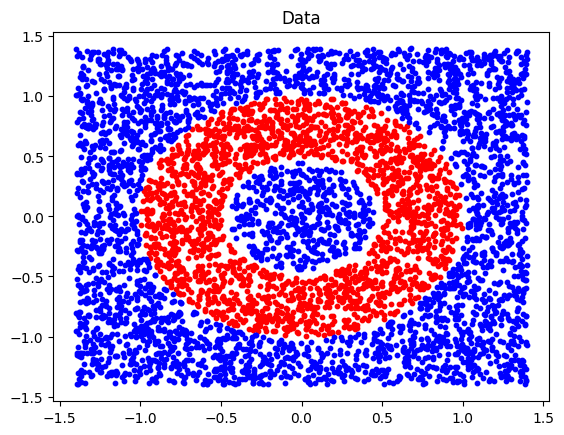

In [14]:
plt.scatter(x0, y0, c = 'red',s=10)
plt.scatter(x1, y1, c = 'blue',s=10)
plt.title("Data")
plt.show()

In [15]:
model = SVC(kernel='rbf', tol=1e-6, max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVC(max_iter=1000, tol=1e-06)

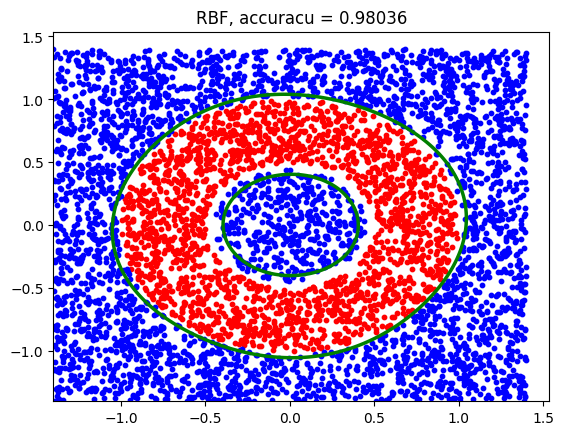

In [16]:
x_min = min(min(x0), min(x1))
x_max = max(max(x0), max(x1))
y_min = min(min(y0), min(y1))
y_max = max(max(y0), max(y1))
h = 0.01  # шаг сетки
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
dic_f = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
dic_f = dic_f.reshape(xx.shape)
pred = model.predict(X_valid)
acc = accuracy_score(pred, y_valid)

plt.contour(xx, yy, dic_f, levels=[0], colors='green', linewidths=2.5)
plt.scatter(x0, y0, c = 'red',s=10)
plt.scatter(x1, y1, c = 'blue',s=10)
plt.title(f"RBF, accuracu = {acc:.5f}")
plt.show()